## Antigen Prediction With Biopython + ESM-2 + ESMFold + Combined-Only HPO

This notebook rebuilds the antigen pipeline end to end from `df_final_dataset_ready.csv` using the raw `Sequence` column.

It is designed to:
- recompute Biopython physicochemical features from sequence
- generate fresh **8M ESM-2** embeddings (`facebook/esm2_t6_8M_UR50D`) from sequence
- predict/cache ESMFold structures and derive `struct_*` features
- build a sequence-similarity graph using global-alignment identity and a `0.90` threshold
- tune hyperparameters only on the `combined` feature set
- reuse those best hyperparameters on `embedding_only` and `structural_only` ablations
- keep overfitting modest with train-fit scaling, dropout, weight decay, and early stopping

Models compared:
- `XGBoost`
- `DNN`
- `GAT`
- `TransformerConv`
- `GPSConv`

Outputs are written under `runs/<RUN_ID>/`.

---

**How to run:** Execute cells **in order** from top to bottom. Each numbered **section 1–9** is a markdown header immediately followed by the **code cell** that performs that step. **Section 10** is optional tips (ESMFold toggle, HPO trials, graph sparsity).

**Prerequisites:** Python packages listed in the first code cell’s comment (`torch`, `torch-geometric`, `transformers`, `biopython`, `xgboost`, `optuna`, etc.).


### 1. Environment, paths, and run configuration

Sets random seeds, selects **CPU or CUDA**, and resolves `df_final_dataset_ready.csv` (current working directory, or the notebook folder in VS Code / Cursor when available).

Defines **similarity threshold**, **ESM-2 / ESMFold** model names, **sequence-length limits** (ESM-2: 1022 residues per chunk with a 1024 tokenizer budget; ESMFold: up to 1024 residues with `add_special_tokens=False`), **HPO** trial counts and search spaces, and creates `runs/<RUN_ID>/` subfolders for datasets, structures, Hugging Face cache, checkpoints, plots, and metrics.

Fails fast with a clear error if the CSV cannot be found.


In [1]:
# If needed on a fresh environment:
# !pip -q install transformers biopython xgboost optuna scikit-learn matplotlib seaborn tqdm
# !pip -q install torch-geometric

from __future__ import annotations

import json
import math
import os
import random
import re
import tempfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    from IPython.display import display
except Exception:

    def display(obj, **_kwargs):
        print(obj)


DATA_FILENAME = "df_final_dataset_ready.csv"


def _resolve_workdir_and_data_csv() -> tuple[Path, Path]:
    cwd = Path.cwd()
    candidates = [cwd]
    nb_path = globals().get("__vsc_ipynb_file__")
    if isinstance(nb_path, str):
        candidates.append(Path(nb_path).resolve().parent)
    for base in candidates:
        cand = base / DATA_FILENAME
        if cand.is_file():
            return base, cand
    return cwd, cwd / DATA_FILENAME


WORKDIR, DATA_CSV = _resolve_workdir_and_data_csv()

ID_COL = "Antigen ID"
SEQ_COL = "Sequence"
Y_COL = "Antigen"

SIM_THRESHOLD = 0.90
# ESM-2: HF models use a 1024-position context. With default tokenizer special tokens (e.g. BOS/EOS),
# at most ~1022 amino-acid tokens fit in one forward pass — so we chunk sequences at 1022 residues.
# The tokenizer's max_length should be 1024 so a full 1022-residue chunk is not truncated away.
ESM2_MAX_RESIDUES_PER_CHUNK = 1022
ESM2_TOKENIZER_MAX_LENGTH = 1024
# ESMFold cell uses add_special_tokens=False; cap folding input at the usual 1024-residue context.
ESMFOLD_MAX_RESIDUES = 1024
MAX_EPOCHS = 80
EARLY_STOPPING_PATIENCE = 8
EARLY_STOPPING_MIN_DELTA = 1e-4
if "RUN_ESMFOLD" not in globals():
    RUN_ESMFOLD = False
HPO_N_TRIALS = 15
HPO_FEATURE_SET = "combined"
REUSE_FEATURE_SETS = ["embedding_only", "structural_only"]

ESM2_MODEL = "facebook/esm2_t6_8M_UR50D"
ESMFOLD_MODEL = "facebook/esmfold_v1"

HPO_SPACE = {
    "xgb": {
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.01, 0.05, 0.1],
        "n_estimators": [100, 300, 500],
        "subsample": [0.7, 0.85, 1.0],
        "min_child_weight": [1, 3, 5],
    },
    "dnn": {
        "lr": [1e-5, 3e-5, 1e-4],
        "weight_decay": [1e-6, 1e-5, 1e-4, 5e-4],
        "dropout": [0.3, 0.5, 0.6],
        "batch_size": [16, 32, 64],
    },
    "gnn": {
        "lr": [1e-3, 3e-3, 5e-3],
        "weight_decay": [1e-5, 1e-4, 5e-4],
        "dropout": [0.3, 0.5],
        "hidden_channels": [32, 64, 96],
    },
}


def make_unique_run_dir(base: Path) -> Path:
    if not base.exists():
        return base
    for i in range(2, 9999):
        candidate = base.parent / f"{base.name}_v{i}"
        if not candidate.exists():
            return candidate
    raise RuntimeError("Could not find a unique run directory name.")


def _save_json(obj: dict, path: Path) -> None:
    path.write_text(json.dumps(obj, indent=2, sort_keys=True))


RUN_ID_BASE = "2026-03-24_antigen_struct_esm2_8M_esmfold_hpo_v1"
RUNS_ROOT = WORKDIR / "runs"
RUN_DIR = RUNS_ROOT / RUN_ID_BASE

DIR_DATASETS = RUN_DIR / "datasets"
DIR_STRUCTURES = RUN_DIR / "structures_esmfold"
DIR_MANIFESTS = RUN_DIR / "manifests"
DIR_CHECKPOINTS_HPO = RUN_DIR / "checkpoints_hpo"
DIR_PLOTS_HPO = RUN_DIR / "plots_hpo"
DIR_METRICS_HPO = RUN_DIR / "metrics_hpo"
DIR_HF_CACHE = RUN_DIR / "hf_cache"

for directory in [
    RUN_DIR,
    DIR_DATASETS,
    DIR_STRUCTURES,
    DIR_MANIFESTS,
    DIR_CHECKPOINTS_HPO,
    DIR_PLOTS_HPO,
    DIR_METRICS_HPO,
    DIR_HF_CACHE,
]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("HF_HOME", str(DIR_HF_CACHE))
os.environ.setdefault("HF_HUB_CACHE", str(DIR_HF_CACHE / "hub"))
os.environ.setdefault("TRANSFORMERS_CACHE", str(DIR_HF_CACHE / "transformers"))
os.environ.setdefault("HF_DATASETS_CACHE", str(DIR_HF_CACHE / "datasets"))

run_config = {
    "seed": SEED,
    "data_csv": str(DATA_CSV),
    "sim_threshold": SIM_THRESHOLD,
    "esm2_max_residues_per_chunk": ESM2_MAX_RESIDUES_PER_CHUNK,
    "esm2_tokenizer_max_length": ESM2_TOKENIZER_MAX_LENGTH,
    "esmfold_max_residues": ESMFOLD_MAX_RESIDUES,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
    "esm2_model": ESM2_MODEL,
    "esmfold_model": ESMFOLD_MODEL,
    "run_esmfold": RUN_ESMFOLD,
    "hpo_n_trials": HPO_N_TRIALS,
    "device": str(DEVICE),
}
_save_json(run_config, DIR_MANIFESTS / "run_config.json")

if not DATA_CSV.is_file():
    raise FileNotFoundError(
        f"Could not find {DATA_FILENAME!r}. Tried cwd={Path.cwd()} and notebook directory (if available). "
        "Set WORKDIR / DATA_CSV manually in this cell if your CSV lives elsewhere."
    )

print("Device:", DEVICE)
print("RUN_DIR:", RUN_DIR)
print("DATA_CSV exists:", DATA_CSV.exists())


Device: cuda
RUN_DIR: /mmfs1/scratch/mmishkatur.rahman/Escape/runs/2026-03-24_antigen_struct_esm2_8M_esmfold_hpo_v1
DATA_CSV exists: True


### 2. Load and clean the input table

Reads **`df_final_dataset_ready.csv`**, keeps `Antigen ID`, `Sequence`, and `Antigen`, uppercases and filters sequences to standard amino acids, removes duplicate IDs, and reports class counts.

**Output:** in-memory `df` used by all following cells.


In [2]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
AA_ALPHABET = set("ACDEFGHIKLMNPQRSTVWY")


def clean_sequence(seq: str) -> str:
    seq = str(seq).upper()
    return "".join(ch for ch in seq if ch in AA_ALPHABET)


df = pd.read_csv(DATA_CSV)
required_cols = [ID_COL, SEQ_COL, Y_COL]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()
df[ID_COL] = df[ID_COL].astype(str)
df[SEQ_COL] = df[SEQ_COL].map(clean_sequence)
df[Y_COL] = pd.to_numeric(df[Y_COL], errors="coerce").fillna(0).astype(int)
df = df[df[SEQ_COL].str.len() > 0].drop_duplicates(subset=[ID_COL]).reset_index(drop=True)
df["seq_length"] = df[SEQ_COL].str.len().astype(int)

print("Loaded dataset:", df.shape)
print("Class counts:")
print(df[Y_COL].value_counts(dropna=False).sort_index())
display(df.head())


Loaded dataset: (492, 4)
Class counts:
Antigen
0    264
1    228
Name: count, dtype: int64


,Antigen ID,Sequence,Antigen,seq_length
0,Ag_1,MKLKNTLGVVIGSLVAASAMNAFAQGQNSVEIEAFGKRYFTDSVRN...,1,350
1,Ag_2,MEVRNLNAARELFLDELLAASAAPASAEQEELLALLRSERIVLAHA...,1,294
2,Ag_3,MNNVLKFSALALAAVLATGCSSHSKETEARLTATEDAAARAQARAD...,1,83
3,Ag_4,MKAQKGFTLIELMIVVAIIGILAAIAIPQYQNYVARSEGASALATI...,1,149
4,Ag_5,GLQIANRLTSQITGVNTAVKNANDGISIAQTAEGALQESTNILQRM...,1,700


### 3. Physicochemical features (Biopython)

For each sequence, computes five descriptors (molecular weight, isoelectric point, instability index, aromaticity, GRAVY) and adds them as `phys_*` columns.

**Output:** `runs/.../datasets/dataset_with_physchem.csv`


In [3]:
def compute_physchem_features(seq: str) -> dict:
    analyzed = ProteinAnalysis(seq)
    return {
        "phys_molecular_weight": float(analyzed.molecular_weight()),
        "phys_isoelectric_point": float(analyzed.isoelectric_point()),
        "phys_instability_index": float(analyzed.instability_index()),
        "phys_aromaticity": float(analyzed.aromaticity()),
        "phys_gravy": float(analyzed.gravy()),
    }


phys_rows = []
for seq in tqdm(df[SEQ_COL].tolist(), desc="Biopython features"):
    phys_rows.append(compute_physchem_features(seq))

phys_df = pd.DataFrame(phys_rows)
df = pd.concat([df.reset_index(drop=True), phys_df.reset_index(drop=True)], axis=1)
phys_cols = [c for c in df.columns if c.startswith("phys_")]

df.to_csv(DIR_DATASETS / "dataset_with_physchem.csv", index=False)
print("Physicochemical columns:", phys_cols)
display(df[[ID_COL, Y_COL] + phys_cols].head())

Biopython features: 100%|██████████| 492/492 [00:00<00:00, 7443.87it/s]

Physicochemical columns: ['phys_molecular_weight', 'phys_isoelectric_point', 'phys_instability_index', 'phys_aromaticity', 'phys_gravy']


,Antigen ID,Antigen,phys_molecular_weight,phys_isoelectric_point,phys_instability_index,phys_aromaticity,phys_gravy
0,Ag_1,1,37639.1423,4.979914,26.154857,0.085714,-0.442571
1,Ag_2,1,32283.0745,5.027943,41.067687,0.068027,-0.257143
2,Ag_3,1,8834.7795,7.896039,17.948193,0.024096,-0.540964
3,Ag_4,1,15511.5941,6.237647,31.377181,0.053691,0.129530
4,Ag_5,1,70811.8612,4.565899,14.134286,0.028571,-0.181571


### 4. ESM-2 embeddings (cached per run)

If `esm2_t6_8M_UR50D_embeddings.csv` exists under this run’s `datasets/` folder, loads it. Otherwise runs **`facebook/esm2_t6_8M_UR50D`** (8M-parameter ESM-2) with mean pooling over tokens (chunks if sequence length exceeds `ESM2_MAX_RESIDUES_PER_CHUNK`), then saves the cache.

Merges `esm2_000` … columns into `df`.

**Output:** `runs/.../datasets/dataset_with_physchem_esm2.csv`


In [4]:
EMB_CACHE_PATH = DIR_DATASETS / "esm2_t6_8M_UR50D_embeddings.csv"

current_ids = [str(x) for x in df[ID_COL].tolist()]
seq_by_id = {str(pid): str(seq) for pid, seq in df[[ID_COL, SEQ_COL]].itertuples(index=False, name=None)}

if EMB_CACHE_PATH.exists():
    embeddings_df = pd.read_csv(EMB_CACHE_PATH)
    if ID_COL not in embeddings_df.columns:
        embeddings_df[ID_COL] = pd.Series(dtype=str)
    embeddings_df[ID_COL] = embeddings_df[ID_COL].astype(str)
    emb_cols_existing = [c for c in embeddings_df.columns if c.startswith("esm2_")]
    if not emb_cols_existing:
        print("Embedding cache exists but has no esm2_* columns; rebuilding cache.")
        missing_ids = current_ids
    else:
        cached_ids = set(embeddings_df[ID_COL].astype(str))
        missing_ids = [pid for pid in current_ids if pid not in cached_ids]
        if missing_ids:
            print(f"Loaded cached embeddings with {len(missing_ids)} missing IDs; generating only missing embeddings.")
        else:
            print("Loaded cached embeddings:", EMB_CACHE_PATH)
else:
    embeddings_df = pd.DataFrame(columns=[ID_COL])
    emb_cols_existing = []
    missing_ids = current_ids

if missing_ids:
    from transformers import AutoModel, AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(ESM2_MODEL, cache_dir=str(DIR_HF_CACHE))
    model = AutoModel.from_pretrained(ESM2_MODEL, cache_dir=str(DIR_HF_CACHE)).to(DEVICE)
    model.eval()

    def split_sequence(sequence: str, chunk_size: int = ESM2_MAX_RESIDUES_PER_CHUNK) -> list[str]:
        return [sequence[i:i + chunk_size] for i in range(0, len(sequence), chunk_size)]

    def embed_sequence(sequence: str) -> np.ndarray:
        chunks = split_sequence(sequence) if len(sequence) > ESM2_MAX_RESIDUES_PER_CHUNK else [sequence]
        chunk_embeddings = []
        for chunk in chunks:
            inputs = tokenizer(
                chunk,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=ESM2_TOKENIZER_MAX_LENGTH,
            )
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = model(**inputs)
            token_embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0)
            chunk_embeddings.append(token_embedding.detach().cpu())
        return torch.stack(chunk_embeddings).mean(dim=0).numpy()

    embeddings = {}
    for pid in tqdm(missing_ids, total=len(missing_ids), desc="ESM-2 embeddings"):
        embeddings[pid] = embed_sequence(seq_by_id[pid])

    new_df = pd.DataFrame.from_dict(embeddings, orient="index")
    new_df.index.name = ID_COL
    new_df = new_df.reset_index()

    new_dim = new_df.shape[1] - 1
    if emb_cols_existing:
        if len(emb_cols_existing) != new_dim:
            raise ValueError(
                f"Cached embedding dim {len(emb_cols_existing)} != newly generated dim {new_dim}."
            )
        new_df.columns = [ID_COL] + emb_cols_existing
        embeddings_df = embeddings_df[[ID_COL] + emb_cols_existing].copy()
    else:
        emb_cols_existing = [f"esm2_{i:03d}" for i in range(new_dim)]
        new_df.columns = [ID_COL] + emb_cols_existing
        if ID_COL in embeddings_df.columns:
            embeddings_df = embeddings_df[[ID_COL]].copy()
        else:
            embeddings_df = pd.DataFrame(columns=[ID_COL])

    embeddings_df[ID_COL] = embeddings_df[ID_COL].astype(str)
    new_df[ID_COL] = new_df[ID_COL].astype(str)
    embeddings_df = pd.concat([embeddings_df, new_df], ignore_index=True)
    embeddings_df = embeddings_df.drop_duplicates(subset=[ID_COL], keep="last")
    embeddings_df.to_csv(EMB_CACHE_PATH, index=False)
    print("Saved embeddings cache:", EMB_CACHE_PATH)

emb_cols = [c for c in embeddings_df.columns if c.startswith("esm2_")]
embeddings_df = embeddings_df[[ID_COL] + emb_cols].copy()
embeddings_df[ID_COL] = embeddings_df[ID_COL].astype(str)
df[ID_COL] = df[ID_COL].astype(str)
missing_after_merge = [pid for pid in current_ids if pid not in set(embeddings_df[ID_COL].astype(str))]
if missing_after_merge:
    raise ValueError(f"Embedding cache is still missing {len(missing_after_merge)} IDs after backfill.")

df = df.merge(embeddings_df, on=ID_COL, how="left", validate="one_to_one")
df.to_csv(DIR_DATASETS / "dataset_with_physchem_esm2.csv", index=False)

print("Embedding columns:", len(emb_cols))
print("Merged dataset shape:", df.shape)
display(df[[ID_COL, Y_COL] + phys_cols + emb_cols[:3]].head())

Loaded cached embeddings: /mmfs1/scratch/mmishkatur.rahman/Escape/runs/2026-03-24_antigen_struct_esm2_8M_esmfold_hpo_v1/datasets/esm2_t6_8M_UR50D_embeddings.csv
Embedding columns: 320
Merged dataset shape: (492, 329)


,Antigen ID,Antigen,phys_molecular_weight,phys_isoelectric_point,phys_instability_index,phys_aromaticity,phys_gravy,esm2_000,esm2_001,esm2_002
0,Ag_1,1,37639.1423,4.979914,26.154857,0.085714,-0.442571,-0.232433,0.009313,0.482436
1,Ag_2,1,32283.0745,5.027943,41.067687,0.068027,-0.257143,-0.132198,-0.153738,0.158175
2,Ag_3,1,8834.7795,7.896039,17.948193,0.024096,-0.540964,-0.273657,0.203581,0.261891
3,Ag_4,1,15511.5941,6.237647,31.377181,0.053691,0.129530,-0.169276,-0.052805,0.145424
4,Ag_5,1,70811.8612,4.565899,14.134286,0.028571,-0.181571,-0.207018,0.188356,0.243900


### 5. Sequence similarity matrix and edge list

Computes pairwise **global alignment identity** with `Bio.pairwise2.align.globalxx` (same spirit as `GNN_Antigen.ipynb`). Reuses `similarity_matrix_seqid.csv` when IDs still match the current `df`; otherwise recomputes.

Keeps **one row per undirected pair** with similarity ≥ **`SIM_THRESHOLD`**.

**Outputs:** `similarity_matrix_seqid.csv`, `edge_list_seqid_threshold_*.csv`


In [5]:
from Bio import pairwise2

SIM_MATRIX_PATH = DIR_DATASETS / "similarity_matrix_seqid.csv"
EDGE_LIST_PATH = DIR_DATASETS / f"edge_list_seqid_threshold_{str(SIM_THRESHOLD).replace('.', 'p')}.csv"


def seq_similarity_globalxx(seq1: str, seq2: str) -> float:
    alns = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    if not alns:
        return float("nan")
    aln = alns[0]
    a1, a2 = aln.seqA, aln.seqB
    matches = sum(1 for x, y in zip(a1, a2) if x == y)
    return float(matches) / float(len(a1)) if len(a1) else float("nan")


print("Skipping duplicate similarity cell. The next cell performs the actual cached/recompute logic.")


Skipping duplicate similarity cell. The next cell performs the actual cached/recompute logic.


/mmfs1/home/mmishkatur.rahman/Venvs/vaccine_esmfold_env/lib/python3.11/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [6]:
from Bio import pairwise2

SIM_MATRIX_PATH = DIR_DATASETS / "similarity_matrix_seqid.csv"
EDGE_LIST_PATH = DIR_DATASETS / f"edge_list_seqid_threshold_{str(SIM_THRESHOLD).replace('.', 'p')}.csv"


def seq_similarity_globalxx(seq1: str, seq2: str) -> float:
    alns = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    if not alns:
        return float("nan")
    aln = alns[0]
    a1, a2 = aln.seqA, aln.seqB
    matches = sum(1 for x, y in zip(a1, a2) if x == y)
    return float(matches) / float(len(a1)) if len(a1) else float("nan")


prot_ids = [str(x) for x in df[ID_COL].tolist()]
seqs = [str(x) for x in df[SEQ_COL].tolist()]

similarity_matrix = None
if SIM_MATRIX_PATH.exists():
    _sm = pd.read_csv(SIM_MATRIX_PATH, index_col=0)
    _sm.index = _sm.index.astype(str)
    _sm.columns = _sm.columns.astype(str)
    _missing = [pid for pid in prot_ids if pid not in _sm.index or pid not in _sm.columns]
    if _missing:
        print(
            "Cached similarity matrix missing",
            len(_missing),
            "IDs vs current dataframe; recomputing matrix.",
        )
    else:
        similarity_matrix = _sm.loc[prot_ids, prot_ids].astype(float)
        print("Loaded cached similarity matrix:", similarity_matrix.shape)

if similarity_matrix is None:
    similarity_matrix = pd.DataFrame(index=prot_ids, columns=prot_ids, dtype=float)
    for i, s1 in tqdm(list(enumerate(seqs)), total=len(seqs), desc="Similarity matrix"):
        similarity_matrix.iat[i, i] = 1.0
        for j in range(i + 1, len(seqs)):
            sim = seq_similarity_globalxx(s1, seqs[j])
            similarity_matrix.iat[i, j] = sim
            similarity_matrix.iat[j, i] = sim
    similarity_matrix.to_csv(SIM_MATRIX_PATH)
    print("Saved similarity matrix:", SIM_MATRIX_PATH)

edge_rows = []
for i in range(len(prot_ids)):
    for j in range(i + 1, len(prot_ids)):
        sim = float(similarity_matrix.iat[i, j])
        if np.isfinite(sim) and sim >= SIM_THRESHOLD:
            edge_rows.append((prot_ids[i], prot_ids[j], sim))

edges_df = pd.DataFrame(edge_rows, columns=["source", "target", "similarity"])
edges_df.to_csv(EDGE_LIST_PATH, index=False)

print("Threshold:", SIM_THRESHOLD)
print("Undirected edges kept:", len(edges_df))
display(edges_df.head())

Loaded cached similarity matrix: (492, 492)
Threshold: 0.9
Undirected edges kept: 1448


,source,target,similarity
0,Ag_16,Neg_28,0.918639
1,Ag_16,Neg_115,0.915789
2,Ag_16,Neg_154,0.987673
3,Ag_16,Neg_155,0.996904
4,Ag_20,Neg_114,0.996078


### 6. ESMFold structures and `struct_*` features

Ensures `manifests/esmfold_manifest.csv` lists every antigen/sequence, optionally runs **ESMFold** when `RUN_ESMFOLD=True` (GPU recommended), stores **mmCIF** under `structures_esmfold/`, and extracts global structural descriptors into `struct_*` columns.

If `structural_features.csv` already exists for this run, loads it instead of recomputing.

**Output:** merged `df` saved as `dataset_with_physchem_esm2_esmfold.csv`


In [7]:
import gc
from Bio.PDB import MMCIFIO, MMCIFParser, PDBParser, PPBuilder, ShrakeRupley
from Bio.PDB.Polypeptide import is_aa
if "RUN_ESMFOLD" not in globals():
    RUN_ESMFOLD = False
MANIFEST_PATH = DIR_MANIFESTS / "esmfold_manifest.csv"
STRUCT_CACHE_PATH = DIR_DATASETS / "structural_features.csv"
ESMFOLD_RETRY_FAILED_AT_LENGTHS = [768, 640, 512, 384, 320, 256]
ESMFOLD_TRUNK_CHUNK_SIZE = 64
ESMFOLD_LOAD_FP16_ON_CUDA = True

MAX_ASA = {
    "A": 121.0, "R": 265.0, "N": 187.0, "D": 187.0, "C": 148.0,
    "Q": 214.0, "E": 214.0, "G": 97.0, "H": 216.0, "I": 195.0,
    "L": 191.0, "K": 230.0, "M": 203.0, "F": 228.0, "P": 154.0,
    "S": 143.0, "T": 163.0, "W": 264.0, "Y": 255.0, "V": 165.0,
}
HYDROPHOBIC = set("AVILMFWY")
CHARGED = set("RKHDE")
STRUCT_FEATURE_ORDER = [
    "mean_plddt",
    "median_plddt",
    "frac_plddt_gt_70",
    "frac_plddt_gt_90",
    "radius_of_gyration",
    "contact_density",
    "long_range_contact_ratio",
    "compactness",
    "helix_fraction",
    "sheet_fraction",
    "coil_fraction",
    "total_sasa",
    "exposed_residue_fraction",
    "hydrophobic_exposed_fraction",
    "charged_exposed_fraction",
]


def seqhash10(seq: str) -> str:
    import hashlib
    return hashlib.sha1(seq.encode("utf-8")).hexdigest()[:10]


def get_structure_path(pid: str, seq: str) -> Path:
    return DIR_STRUCTURES / f"{pid}__{seqhash10(seq)}.cif"


def _normalize_manifest_dtypes(dfm: pd.DataFrame) -> pd.DataFrame:
    """Avoid pandas inferring float64 for empty status/error columns after read_csv."""
    dfm = dfm.copy()
    for col in ("status", "error", "structure_path", "seqhash10"):
        if col in dfm.columns:
            dfm[col] = dfm[col].fillna("").astype(str)
    if ID_COL in dfm.columns:
        dfm[ID_COL] = dfm[ID_COL].astype(str)
    if "length" in dfm.columns:
        dfm["length"] = pd.to_numeric(dfm["length"], errors="coerce").fillna(0).astype(int)
    return dfm
def load_manifest(path: Path) -> pd.DataFrame:
    if path.exists():
        dfm = pd.read_csv(path)
    else:
        dfm = pd.DataFrame(columns=[ID_COL, "seqhash10", "length", "structure_path", "status", "error"])
    return _normalize_manifest_dtypes(dfm)
def save_manifest(dfm: pd.DataFrame) -> None:
    dfm.to_csv(MANIFEST_PATH, index=False)
def ensure_manifest_rows(df_in: pd.DataFrame) -> pd.DataFrame:
    dfm = load_manifest(MANIFEST_PATH)
    existing = set(
        zip(
            dfm.get(ID_COL, pd.Series(dtype=str)).astype(str),
            dfm.get("seqhash10", pd.Series(dtype=str)).astype(str),
        )
    )
    new_rows = []
    for pid, seq in df_in[[ID_COL, SEQ_COL]].itertuples(index=False, name=None):
        h = seqhash10(seq)
        key = (str(pid), h)
        if key in existing:
            continue
        new_rows.append(
            {
                ID_COL: str(pid),
                "seqhash10": h,
                "length": len(seq),
                "structure_path": str(get_structure_path(str(pid), seq)),
                "status": "pending",
                "error": "",
            }
        )
    if new_rows:
        dfm = pd.concat([dfm, pd.DataFrame(new_rows)], ignore_index=True)
        dfm = _normalize_manifest_dtypes(dfm)
        save_manifest(dfm)
    return dfm


def save_pdb_str_as_mmcif(pdb_str: str, cif_path: Path) -> None:
    cif_path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile("w", suffix=".pdb", delete=False) as tmp:
        tmp.write(pdb_str)
        tmp_path = Path(tmp.name)
    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure("pred", str(tmp_path))
        io = MMCIFIO()
        io.set_structure(structure)
        io.save(str(cif_path))
    finally:
        tmp_path.unlink(missing_ok=True)


def _hf_outputs_to_pdb_strings(outputs) -> List[str]:
    from transformers.models.esm.openfold_utils.feats import atom14_to_atom37
    from transformers.models.esm.openfold_utils.protein import Protein as OFProtein, to_pdb

    final_atom_positions = atom14_to_atom37(outputs["positions"][-1], outputs)
    out_np = {k: (v.detach().cpu().numpy() if hasattr(v, "detach") else v) for k, v in outputs.items()}
    final_atom_positions = np.asarray(final_atom_positions.detach().cpu().numpy())
    final_atom_mask = np.asarray(out_np["atom37_atom_exists"])
    aatype = np.asarray(out_np["aatype"])
    residue_index = np.asarray(out_np["residue_index"])
    b_factors = out_np.get("plddt")
    chain_index = out_np.get("chain_index")
    if b_factors is not None:
        b_factors = np.asarray(b_factors)
    if chain_index is not None:
        chain_index = np.asarray(chain_index)

    # Normalize to batched shapes for robust handling across transformer versions.
    if aatype.ndim == 1:
        aatype = aatype[None, :]
    if residue_index.ndim == 1:
        residue_index = residue_index[None, :]
    if final_atom_positions.ndim == 3:
        final_atom_positions = final_atom_positions[None, :, :, :]
    if final_atom_mask.ndim == 2:
        final_atom_mask = final_atom_mask[None, :, :]
    if b_factors is not None and b_factors.ndim == 1:
        b_factors = b_factors[None, :]
    if chain_index is not None and chain_index.ndim == 1:
        chain_index = chain_index[None, :]

    pdbs = []
    batch = min(
        aatype.shape[0],
        residue_index.shape[0],
        final_atom_positions.shape[0],
        final_atom_mask.shape[0],
    )
    if batch <= 0:
        return pdbs
    for i in range(batch):
        resid = residue_index[i] + 1
        bf = b_factors[i] if (b_factors is not None and b_factors.shape[0] > i) else np.zeros_like(resid, dtype=float)
        ci = chain_index[i] if (chain_index is not None and chain_index.shape[0] > i) else None
        pred = OFProtein(
            aatype=aatype[i],
            atom_positions=final_atom_positions[i],
            atom_mask=final_atom_mask[i],
            residue_index=resid,
            b_factors=bf,
            chain_index=ci,
        )
        pdbs.append(to_pdb(pred))
    return pdbs


def _is_cuda_oom(exc: Exception) -> bool:
    msg = repr(exc).lower()
    return ("out of memory" in msg) and ("cuda" in msg or "cublas" in msg or "cudnn" in msg)


def _is_retryable_esmfold_error(exc: Exception) -> bool:
    if _is_cuda_oom(exc):
        return True
    if isinstance(exc, IndexError):
        return True
    msg = repr(exc).lower()
    return (
        "index 0 is out of bounds" in msg
        or "out of bounds for dimension 0" in msg
        or "returned empty" in msg
    )


def _clear_cuda_memory() -> None:
    if torch.cuda.is_available():
        try:
            torch.cuda.empty_cache()
        except RuntimeError as e:
            if "device-side assert triggered" in repr(e).lower():
                return
            raise
        try:
            torch.cuda.ipc_collect()
        except RuntimeError as e:
            if "device-side assert triggered" in repr(e).lower():
                return
            raise
        except Exception:
            pass
    gc.collect()


def _esmfold_attempt_lengths(seq_len: int) -> List[int]:
    primary = min(seq_len, ESMFOLD_MAX_RESIDUES)
    lengths = [primary]
    for retry_len in ESMFOLD_OOM_RETRY_LENGTHS:
        if retry_len < primary:
            lengths.append(int(retry_len))
    if ESMFOLD_MIN_FALLBACK_LENGTH < primary:
        lengths.append(int(ESMFOLD_MIN_FALLBACK_LENGTH))
    return sorted(set(lengths), reverse=True)


def predict_structures_with_esmfold(df_in: pd.DataFrame) -> pd.DataFrame:
    from transformers import AutoTokenizer, EsmForProteinFolding

    manifest_df = ensure_manifest_rows(df_in)
    pending_count = 0
    for _, row in df_in.iterrows():
        pid = str(row[ID_COL])
        seq = str(row[SEQ_COL])
        h = seqhash10(seq)
        mask = (manifest_df[ID_COL].astype(str) == pid) & (manifest_df["seqhash10"].astype(str) == h)
        _ix = np.flatnonzero(mask.values)
        if _ix.size == 0:
            continue
        mi = int(_ix[0])
        out_path = get_structure_path(pid, seq)
        if out_path.exists():
            if str(manifest_df.loc[mi, "status"]) not in {"ok", "ok_truncated", "cached", "cached_converted"}:
                manifest_df.loc[mi, "status"] = "cached"
                manifest_df.loc[mi, "error"] = ""
        else:
            pending_count += 1

    if pending_count == 0:
        print("All ESMFold structures are already cached; skipping model load.")
        save_manifest(manifest_df)
        return manifest_df

    if DEVICE.type == "cuda":
        _clear_cuda_memory()
        free_b, total_b = torch.cuda.mem_get_info()
        print(f"CUDA free before ESMFold load: {free_b / (1024**3):.2f} / {total_b / (1024**3):.2f} GiB")

    tokenizer = AutoTokenizer.from_pretrained(ESMFOLD_MODEL, cache_dir=str(DIR_HF_CACHE))
    load_kwargs = {
        "low_cpu_mem_usage": True,
        "cache_dir": str(DIR_HF_CACHE),
    }
    if DEVICE.type == "cuda" and ESMFOLD_LOAD_FP16_ON_CUDA:
        load_kwargs["torch_dtype"] = torch.float16
    model = EsmForProteinFolding.from_pretrained(ESMFOLD_MODEL, **load_kwargs)

    try:
        model = model.to(DEVICE)
    except torch.OutOfMemoryError as e:
        _clear_cuda_memory()
        raise RuntimeError(
            "CUDA OOM while loading ESMFold model. Restart kernel or free GPU memory, then retry Section 6."
        ) from e

    if DEVICE.type == "cuda":
        torch.backends.cuda.matmul.allow_tf32 = True
        try:
            model.esm = model.esm.half()
        except Exception:
            pass
        try:
            model.trunk.set_chunk_size(int(ESMFOLD_TRUNK_CHUNK_SIZE))
        except Exception:
            pass

    model.eval()

    def _run_fold_pass(df_pass: pd.DataFrame, max_len: int, pass_label: str) -> tuple[int, int]:
        nonlocal manifest_df
        attempted = 0
        succeeded = 0

        for idx, row in tqdm(df_pass.iterrows(), total=len(df_pass), desc=f"ESMFold ({pass_label}, max_len={max_len})"):
            pid = str(row[ID_COL])
            seq = str(row[SEQ_COL])
            seq_clean = clean_sequence(seq)
            out_path = get_structure_path(pid, seq)

            h = seqhash10(seq)
            mask = (manifest_df[ID_COL].astype(str) == pid) & (manifest_df["seqhash10"].astype(str) == h)
            _ix = np.flatnonzero(mask.values)
            if _ix.size == 0:
                manifest_df = ensure_manifest_rows(df_in)
                mask = (manifest_df[ID_COL].astype(str) == pid) & (manifest_df["seqhash10"].astype(str) == h)
                _ix = np.flatnonzero(mask.values)
            if _ix.size == 0:
                continue
            mi = int(_ix[0])

            if out_path.exists():
                manifest_df.loc[mi, "status"] = "cached"
                manifest_df.loc[mi, "error"] = ""
                if (idx % 10) == 0:
                    save_manifest(manifest_df)
                continue

            if len(seq_clean) == 0:
                manifest_df.loc[mi, "status"] = "failed"
                manifest_df.loc[mi, "error"] = "empty_sequence_after_cleaning"
                if (idx % 10) == 0:
                    save_manifest(manifest_df)
                continue

            attempted += 1
            truncated = False
            if len(seq_clean) > int(max_len):
                seq_clean = seq_clean[: int(max_len)]
                truncated = True

            try:
                inputs = tokenizer([seq_clean], return_tensors="pt", add_special_tokens=False)
                inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                with torch.no_grad():
                    outputs = model(**inputs)
                pdbs = _hf_outputs_to_pdb_strings(outputs)
                if not pdbs:
                    raise RuntimeError("empty_pdb_output")
                save_pdb_str_as_mmcif(pdbs[0], out_path)
                manifest_df.loc[mi, "status"] = "ok_truncated" if truncated else "ok"
                manifest_df.loc[mi, "error"] = "" if not truncated else f"truncated_to_{int(max_len)}"
                succeeded += 1
            except torch.OutOfMemoryError as e:
                manifest_df.loc[mi, "status"] = "failed"
                manifest_df.loc[mi, "error"] = f"oom_maxlen_{int(max_len)}: {repr(e)[:430]}"
                if DEVICE.type == "cuda":
                    _clear_cuda_memory()
            except Exception as e:
                manifest_df.loc[mi, "status"] = "failed"
                manifest_df.loc[mi, "error"] = repr(e)[:500]
            finally:
                if (idx % 10) == 0:
                    save_manifest(manifest_df)

        save_manifest(manifest_df)
        print(f"{pass_label}: attempted={attempted}, succeeded={succeeded}, failed={max(0, attempted - succeeded)}")
        return attempted, succeeded

    base_len = int(ESMFOLD_MAX_RESIDUES)
    _run_fold_pass(df_in, base_len, "base")

    for retry_len in ESMFOLD_RETRY_FAILED_AT_LENGTHS:
        manifest_df = load_manifest(MANIFEST_PATH)
        failed_ids = set(manifest_df.loc[manifest_df["status"].astype(str) == "failed", ID_COL].astype(str))
        if not failed_ids:
            break
        df_failed = df_in[df_in[ID_COL].astype(str).isin(failed_ids)].copy()
        if df_failed.empty:
            break
        retry_len = int(min(retry_len, base_len))
        print(f"Retrying failed proteins only: n={len(df_failed)}, max_len={retry_len}")
        _run_fold_pass(df_failed, retry_len, "retry_failed")

    manifest_df = load_manifest(MANIFEST_PATH)

    return manifest_df


def parse_structure_file(structure_path: Path):
    parser = MMCIFParser(QUIET=True) if structure_path.suffix.lower() == ".cif" else PDBParser(QUIET=True)
    return parser.get_structure(structure_path.stem, str(structure_path))


def get_residue_ca_table(structure) -> pd.DataFrame:
    rows = []
    for model in structure:
        for chain in model:
            for residue in chain:
                if not is_aa(residue, standard=True) or "CA" not in residue:
                    continue
                ca = residue["CA"]
                x, y, z = ca.get_coord()
                rows.append({
                    "chain_id": chain.id,
                    "resseq": int(residue.id[1]),
                    "x": float(x),
                    "y": float(y),
                    "z": float(z),
                    "bfactor_ca": float(ca.get_bfactor()),
                })
    return pd.DataFrame(rows)


def radius_of_gyration(coords: np.ndarray) -> float:
    if coords.size == 0:
        return float("nan")
    centroid = coords.mean(axis=0)
    return float(np.sqrt(np.mean(np.sum((coords - centroid) ** 2, axis=1))))


def contact_features(coords: np.ndarray, chain_ids: np.ndarray, seq_ids: np.ndarray, cutoff: float = 8.0) -> dict:
    n = coords.shape[0]
    if n <= 1:
        return {"contact_density": float("nan"), "long_range_contact_ratio": float("nan")}
    d2 = np.sum((coords[:, None, :] - coords[None, :, :]) ** 2, axis=-1)
    within = (d2 > 0) & (d2 <= cutoff ** 2)
    num_contacts = float(np.sum(within) / 2.0)
    same_chain = chain_ids[:, None] == chain_ids[None, :]
    long_range = same_chain & (np.abs(seq_ids[:, None] - seq_ids[None, :]) >= 24)
    long_contacts = float(np.sum(within & long_range) / 2.0)
    return {
        "contact_density": num_contacts / float(n),
        "long_range_contact_ratio": (long_contacts / num_contacts) if num_contacts > 0 else float("nan"),
    }


def compactness_feature(n_residues: int, rg: float) -> float:
    if not np.isfinite(rg) or rg <= 0 or n_residues <= 0:
        return float("nan")
    return float(n_residues / (rg ** 3))


def classify_phi_psi(phi, psi):
    if phi is None or psi is None:
        return None
    phi_deg = np.degrees(phi)
    psi_deg = np.degrees(psi)
    if (-100 <= phi_deg <= -30) and (-80 <= psi_deg <= 0):
        return "helix"
    if (-180 <= phi_deg <= -90) and (90 <= psi_deg <= 180):
        return "sheet"
    return "coil"


def secondary_structure_fractions(structure) -> dict:
    labels = []
    for peptide in PPBuilder().build_peptides(structure):
        for phi, psi in peptide.get_phi_psi_list():
            label = classify_phi_psi(phi, psi)
            if label is not None:
                labels.append(label)
    if not labels:
        return {"helix_fraction": float("nan"), "sheet_fraction": float("nan"), "coil_fraction": float("nan")}
    n = float(len(labels))
    return {
        "helix_fraction": float(labels.count("helix") / n),
        "sheet_fraction": float(labels.count("sheet") / n),
        "coil_fraction": float(labels.count("coil") / n),
    }


def compute_sasa_features(structure, rsa_exposed_threshold: float = 0.20) -> dict:
    model = next(structure.get_models())
    sr = ShrakeRupley(probe_radius=1.4, n_points=960)
    sr.compute(model, level="A")
    total_sasa = 0.0
    per_res = []
    for chain in model:
        for residue in chain:
            if not is_aa(residue, standard=True):
                continue
            res_sasa = 0.0
            for atom in residue.get_atoms():
                sasa = getattr(atom, "sasa", None)
                if sasa is not None and np.isfinite(sasa):
                    total_sasa += float(sasa)
                    res_sasa += float(sasa)
            try:
                from Bio.SeqUtils import seq1
                aa1 = seq1(residue.get_resname())
            except Exception:
                aa1 = None
            max_asa = MAX_ASA.get(aa1) if aa1 else None
            rsa = (res_sasa / max_asa) if (max_asa and max_asa > 0) else float("nan")
            per_res.append({"aa1": aa1, "rsa": rsa})
    per_res_df = pd.DataFrame(per_res)
    if per_res_df.empty:
        return {
            "total_sasa": float("nan"),
            "exposed_residue_fraction": float("nan"),
            "hydrophobic_exposed_fraction": float("nan"),
            "charged_exposed_fraction": float("nan"),
        }
    exposed = per_res_df["rsa"] > rsa_exposed_threshold
    aa1 = per_res_df["aa1"].fillna("")
    return {
        "total_sasa": float(total_sasa),
        "exposed_residue_fraction": float(np.nanmean(exposed.astype(float))),
        "hydrophobic_exposed_fraction": float(np.nanmean((exposed & aa1.isin(list(HYDROPHOBIC))).astype(float))),
        "charged_exposed_fraction": float(np.nanmean((exposed & aa1.isin(list(CHARGED))).astype(float))),
    }


def plddt_summary_from_ca_bfactor(res_df: pd.DataFrame) -> dict:
    p = pd.to_numeric(res_df["bfactor_ca"], errors="coerce")
    p = p[np.isfinite(p)]
    if len(p) == 0:
        return {"mean_plddt": float("nan"), "median_plddt": float("nan"), "frac_plddt_gt_70": float("nan"), "frac_plddt_gt_90": float("nan")}
    if float(np.max(p)) <= 1.5:
        p = p * 100.0
    return {
        "mean_plddt": float(np.mean(p)),
        "median_plddt": float(np.median(p)),
        "frac_plddt_gt_70": float(np.mean(p > 70.0)),
        "frac_plddt_gt_90": float(np.mean(p > 90.0)),
    }


def extract_structural_features(structure_path: Path) -> Dict[str, float]:
    structure = parse_structure_file(structure_path)
    res_df = get_residue_ca_table(structure)
    coords = res_df[["x", "y", "z"]].to_numpy(dtype=float)
    rg = radius_of_gyration(coords)
    contact_feats = contact_features(coords, res_df["chain_id"].to_numpy(), res_df["resseq"].to_numpy(dtype=int)) if len(res_df) else {"contact_density": float("nan"), "long_range_contact_ratio": float("nan")}
    ss_fracs = secondary_structure_fractions(structure)
    sasa_feats = compute_sasa_features(structure)
    plddt_feats = (
        plddt_summary_from_ca_bfactor(res_df)
        if len(res_df)
        else {"mean_plddt": float("nan"), "median_plddt": float("nan"), "frac_plddt_gt_70": float("nan"), "frac_plddt_gt_90": float("nan")}
    )
    feats = {
        **plddt_feats,
        "radius_of_gyration": float(rg),
        "contact_density": float(contact_feats.get("contact_density", np.nan)),
        "long_range_contact_ratio": float(contact_feats.get("long_range_contact_ratio", np.nan)),
        "compactness": float(compactness_feature(len(res_df), rg)),
        "helix_fraction": float(ss_fracs.get("helix_fraction", np.nan)),
        "sheet_fraction": float(ss_fracs.get("sheet_fraction", np.nan)),
        "coil_fraction": float(ss_fracs.get("coil_fraction", np.nan)),
        "total_sasa": float(sasa_feats.get("total_sasa", np.nan)),
        "exposed_residue_fraction": float(sasa_feats.get("exposed_residue_fraction", np.nan)),
        "hydrophobic_exposed_fraction": float(sasa_feats.get("hydrophobic_exposed_fraction", np.nan)),
        "charged_exposed_fraction": float(sasa_feats.get("charged_exposed_fraction", np.nan)),
    }
    return {k: float(feats.get(k, np.nan)) for k in STRUCT_FEATURE_ORDER}


manifest_df = ensure_manifest_rows(df)
if RUN_ESMFOLD:
    manifest_df = predict_structures_with_esmfold(df)
else:
    print("Skipping ESMFold folding. Set RUN_ESMFOLD=True to generate structures.")

status_counts = manifest_df["status"].astype(str).value_counts(dropna=False)
print("ESMFold manifest status counts:")
print(status_counts.to_string())
failed_df = manifest_df[manifest_df["status"].astype(str) == "failed"]
if len(failed_df):
    print("Failed structures:", len(failed_df))
    display(failed_df[[ID_COL, "length", "error"]].head(10))

manifest_df = load_manifest(MANIFEST_PATH)
ok_statuses = {"ok", "ok_truncated", "cached", "cached_converted"}
struct_cols = [f"struct_{k}" for k in STRUCT_FEATURE_ORDER]

if STRUCT_CACHE_PATH.exists():
    struct_df = pd.read_csv(STRUCT_CACHE_PATH)
    print("Loaded cached structural features:", struct_df.shape)
    if ID_COL not in struct_df.columns:
        struct_df[ID_COL] = pd.Series(dtype=str)
    for col in struct_cols:
        if col not in struct_df.columns:
            struct_df[col] = np.nan
    struct_df[ID_COL] = struct_df[ID_COL].astype(str)
    nan_only_ids = set(struct_df.loc[struct_df[struct_cols].isna().all(axis=1), ID_COL].astype(str))
    cached_ids = set(struct_df[ID_COL].astype(str))
    target_ids = set(manifest_df[ID_COL].astype(str)) - (cached_ids - nan_only_ids)
else:
    struct_df = pd.DataFrame(columns=[ID_COL] + struct_cols)
    target_ids = set(manifest_df[ID_COL].astype(str))
    print("No cached structural features found. Building from manifest.")

if target_ids:
    print(f"Backfilling structural features for {len(target_ids)} proteins.")
    rows = []
    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc="Structural features"):
        pid = str(row[ID_COL])
        if pid not in target_ids:
            continue
        structure_path = Path(str(row["structure_path"]))
        status = str(row.get("status", ""))
        if status not in ok_statuses or not structure_path.exists():
            rows.append({ID_COL: pid, **{f"struct_{k}": float("nan") for k in STRUCT_FEATURE_ORDER}})
            continue
        try:
            feats = extract_structural_features(structure_path)
            rows.append({ID_COL: pid, **{f"struct_{k}": feats[k] for k in STRUCT_FEATURE_ORDER}})
        except Exception:
            rows.append({ID_COL: pid, **{f"struct_{k}": float("nan") for k in STRUCT_FEATURE_ORDER}})
    if not struct_df.empty:
        struct_df = struct_df[~struct_df[ID_COL].astype(str).isin(target_ids)]
    struct_df = pd.concat([struct_df, pd.DataFrame(rows)], ignore_index=True)
    struct_df.to_csv(STRUCT_CACHE_PATH, index=False)
    print("Saved structural features:", STRUCT_CACHE_PATH)
else:
    print("Cached structural features already complete; no backfill needed.")

struct_df = struct_df.groupby(ID_COL, as_index=False).mean(numeric_only=True)
df = df.merge(struct_df, on=ID_COL, how="left", validate="one_to_one")
df.to_csv(DIR_DATASETS / "dataset_with_physchem_esm2_esmfold.csv", index=False)

print("Structural columns:", len(struct_cols))
display(df[[ID_COL, Y_COL] + struct_cols[:5]].head())


Skipping ESMFold folding. Set RUN_ESMFOLD=True to generate structures.
ESMFold manifest status counts:
status
cached          441
ok               50
ok_truncated      1
Loaded cached structural features: (492, 16)
Cached structural features already complete; no backfill needed.
Structural columns: 15


,Antigen ID,Antigen,struct_mean_plddt,struct_median_plddt,struct_frac_plddt_gt_70,struct_frac_plddt_gt_90,struct_radius_of_gyration
0,Ag_1,1,89.365714,93.0,0.931429,0.602857,33.597627
1,Ag_2,1,79.452381,83.0,0.802721,0.238095,30.328667
2,Ag_3,1,88.397590,92.0,0.939759,0.578313,35.958081
3,Ag_4,1,88.046980,92.0,0.919463,0.590604,23.419090
4,Ag_5,1,76.355714,82.0,0.725714,0.242857,33.474292


In [8]:
struct_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 492 entries, 0 to 491
Data columns (total 16 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Antigen ID                           492 non-null    str    
 1   struct_mean_plddt                    492 non-null    float64
 2   struct_median_plddt                  492 non-null    float64
 3   struct_frac_plddt_gt_70              492 non-null    float64
 4   struct_frac_plddt_gt_90              492 non-null    float64
 5   struct_radius_of_gyration            492 non-null    float64
 6   struct_contact_density               492 non-null    float64
 7   struct_long_range_contact_ratio      492 non-null    float64
 8   struct_compactness                   492 non-null    float64
 9   struct_helix_fraction                492 non-null    float64
 10  struct_sheet_fraction                492 non-null    float64
 11  struct_coil_fraction                 492 no

### 7. Graph, feature ablations, and stratified split

Builds **PyTorch Geometric** `edge_index`: **both directions** for message passing, **no self-loops** (same style as the vaccine notebook). Defines three feature bundles:

- **`embedding_only`:** `phys_*` + `esm2_*`
- **`structural_only`:** `phys_*` + `struct_*`
- **`combined`:** all of the above

Applies **stratified 80% / 10% / 10%** train / validation / test masks and train-only scaling for `phys_*` and `struct_*` (no leakage).

**Outputs:** `edge_index_seqid_threshold_*.pt`, `split_seed_*.csv`


In [9]:
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, GCNConv, GPSConv, TransformerConv

phys_cols = [c for c in df.columns if c.startswith("phys_")]
emb_cols = [c for c in df.columns if c.startswith("esm2_")]
struct_cols = [c for c in df.columns if c.startswith("struct_")]

FEATURE_SETS = {}
base_cols = phys_cols if phys_cols else []
if emb_cols:
    FEATURE_SETS["embedding_only"] = base_cols + emb_cols
if struct_cols:
    FEATURE_SETS["structural_only"] = base_cols + struct_cols
if emb_cols and struct_cols:
    FEATURE_SETS["combined"] = base_cols + emb_cols + struct_cols

if not FEATURE_SETS:
    raise ValueError(
        "No usable feature columns found. Expected at least one of esm2_* or struct_* (optionally with phys_*)."
    )

if HPO_FEATURE_SET not in FEATURE_SETS:
    if "combined" in FEATURE_SETS:
        HPO_FEATURE_SET = "combined"
    elif "structural_only" in FEATURE_SETS:
        HPO_FEATURE_SET = "structural_only"
    else:
        HPO_FEATURE_SET = "embedding_only"
    print(f"HPO_FEATURE_SET not available in current df; using '{HPO_FEATURE_SET}'")

REUSE_FEATURE_SETS = [fs for fs in REUSE_FEATURE_SETS if fs in FEATURE_SETS and fs != HPO_FEATURE_SET]
if not REUSE_FEATURE_SETS:
    print("No additional reuse feature sets available for this dataframe.")

prot_ids = df[ID_COL].tolist()
id_to_idx = {pid: i for i, pid in enumerate(prot_ids)}

# Match the vaccine notebook approach: one undirected edge in edges_df,
# then store both directions in edge_index for PyG message passing.
edge_pairs = []
for src, tgt in edges_df[["source", "target"]].itertuples(index=False, name=None):
    i = id_to_idx[str(src)]
    j = id_to_idx[str(tgt)]
    edge_pairs.append((i, j))
    edge_pairs.append((j, i))
if edge_pairs:
    edge_index = torch.tensor(np.array(edge_pairs, dtype=np.int64).T, dtype=torch.long)
else:
    edge_index = torch.empty((2, 0), dtype=torch.long)
    print("WARNING: No edges above SIM_THRESHOLD; GNNs will run on an edgeless graph.")

_thresh_tag = str(SIM_THRESHOLD).replace(".", "p")
torch.save(edge_index, DIR_DATASETS / f"edge_index_seqid_threshold_{_thresh_tag}.pt")

y = torch.tensor(df[Y_COL].to_numpy(dtype=int), dtype=torch.long)
idx = np.arange(len(prot_ids))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, stratify=y.numpy(), random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y.numpy()[temp_idx], random_state=SEED)

train_mask = torch.zeros(len(prot_ids), dtype=torch.bool)
val_mask = torch.zeros(len(prot_ids), dtype=torch.bool)
test_mask = torch.zeros(len(prot_ids), dtype=torch.bool)
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

split_df = pd.DataFrame({
    ID_COL: prot_ids,
    "split": np.where(train_mask.numpy(), "train", np.where(val_mask.numpy(), "val", "test")),
})
split_df.to_csv(DIR_DATASETS / f"split_seed_{SEED}.csv", index=False)


def _mask_np(mask_t: torch.Tensor) -> np.ndarray:
    return mask_t.detach().cpu().numpy().astype(bool)


def _scale_phys_struct_trainfit(X: np.ndarray, cols: List[str], train_mask_t: torch.Tensor) -> np.ndarray:
    X = np.asarray(X, dtype=float)
    train_mask_np = _mask_np(train_mask_t)
    scale_idx = [i for i, c in enumerate(cols) if c.startswith("phys_") or c.startswith("struct_")]
    if not scale_idx:
        return X
    Xs = X[:, scale_idx].copy()
    Xs_train = Xs[train_mask_np].copy()
    Xs_train[~np.isfinite(Xs_train)] = np.nan
    means = np.nanmean(Xs_train, axis=0)
    stds = np.nanstd(Xs_train, axis=0)
    means = np.where(np.isfinite(means), means, 0.0)
    stds = np.where(np.isfinite(stds) & (stds > 0), stds, 1.0)
    nonfinite = ~np.isfinite(Xs)
    if np.any(nonfinite):
        Xs[nonfinite] = np.take(means, np.where(nonfinite)[1])
    Xs = (Xs - means) / stds
    X_out = X.copy()
    X_out[:, scale_idx] = Xs
    return X_out


def _build_X_y(fs_name: str) -> tuple[np.ndarray, np.ndarray, list[str]]:
    cols = FEATURE_SETS[fs_name]
    X = df[cols].to_numpy(dtype=float)
    y_np = df[Y_COL].to_numpy(dtype=int)
    X = _scale_phys_struct_trainfit(X, cols, train_mask)
    X = np.where(np.isfinite(X), X, 0.0)
    return X, y_np, cols


print("Split sizes:", int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))
print("edge_index shape:", tuple(edge_index.shape))
print({k: len(v) for k, v in FEATURE_SETS.items()})


Split sizes: 393 49 50
edge_index shape: (2, 2896)
{'embedding_only': 325, 'structural_only': 20, 'combined': 340}


### 8. Neural models, training helpers, and metrics

Defines **DNN**, **GAT (GATv2Conv)**, **TransformerConv**, and **GPSConv** classifiers, **early stopping**, loss-curve plotting, and **`compute_binary_metrics`** (accuracy, precision, recall, F1, ROC-AUC, log loss).

This cell only **declares** code; training runs in the next section.


In [10]:
from sklearn.metrics import accuracy_score, f1_score, log_loss, precision_score, recall_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset


class GATBinaryClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, heads: int = 8, dropout: float = 0.5):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATv2Conv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.leaky_relu(x)
        x = self.conv2(x, edge_index)
        return x


class TransformerConvBinaryClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, heads: int = 8, dropout: float = 0.5):
        super().__init__()
        self.conv1 = TransformerConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = TransformerConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.leaky_relu(x)
        x = self.conv2(x, edge_index)
        return x


class GPSBinaryClassifier(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, heads: int = 8, dropout: float = 0.5, num_layers: int = 2):
        super().__init__()
        self.lin_in = nn.Linear(in_channels, hidden_channels)
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            local_conv = GCNConv(hidden_channels, hidden_channels)
            self.layers.append(
                GPSConv(
                    channels=hidden_channels,
                    conv=local_conv,
                    heads=heads,
                    dropout=dropout,
                    norm="batch_norm",
                    attn_type="multihead",
                )
            )
        self.lin_out = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch=None):
        if batch is None:
            batch = x.new_zeros(x.size(0), dtype=torch.long)
        x = self.lin_in(x)
        for layer in self.layers:
            x = layer(x, edge_index, batch=batch)
            x = F.leaky_relu(x)
        x = self.lin_out(x)
        return x


class DNNModel(nn.Module):
    def __init__(self, input_dim: int, dropout: float = 0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(128, 64)
        self.dropout3 = nn.Dropout(dropout)
        self.output = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        return torch.sigmoid(self.output(x))


@dataclass
class EarlyStopping:
    patience: int = EARLY_STOPPING_PATIENCE
    min_delta: float = EARLY_STOPPING_MIN_DELTA
    best: float = float("inf")
    bad_epochs: int = 0
    best_state: Optional[dict] = None

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < (self.best - self.min_delta):
            self.best = float(val_loss)
            self.bad_epochs = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience


def plot_loss(history: dict, title: str, out_path: Path) -> None:
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def compute_binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float("nan"),
        "log_loss": float("nan"),
    }
    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except Exception:
        pass
    try:
        metrics["log_loss"] = float(log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6)))
    except Exception:
        pass
    return metrics

### 9. Hyperparameter optimization and ablation evaluation

- **Tunes** XGBoost (RandomizedSearchCV) and DNN / GNNs (**Optuna**) on the **`combined`** feature set only.
- Saves best configs and trial tables under **`metrics_hpo/`**.
- **Reuses** those hyperparameters on **`embedding_only`** and **`structural_only`** without extra search.

**Requires:** `optuna` installed; GPU speeds up neural models but is not mandatory.


In [11]:
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from xgboost import XGBClassifier

try:
    import optuna
except Exception as e:
    raise ImportError("Optuna is required for HPO. Install with: python -m pip install -U optuna") from e


def train_eval_dnn(
    X: np.ndarray,
    y_np: np.ndarray,
    *,
    lr: float,
    weight_decay: float,
    dropout: float,
    batch_size: int,
    trial: optuna.Trial | None = None,
    save_name: str | None = None,
    save_dirs: bool = False,
) -> tuple[float, dict, dict, dict]:
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.float32)

    X_train, y_train = X_t[train_mask], y_t[train_mask]
    X_val, y_val = X_t[val_mask], y_t[val_mask]
    X_test, y_test = X_t[test_mask], y_t[test_mask]

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=int(batch_size), shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=int(batch_size), shuffle=False)

    model = DNNModel(input_dim=X.shape[1], dropout=float(dropout)).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=float(lr), weight_decay=float(weight_decay))
    criterion = nn.BCELoss()
    stopper = EarlyStopping()
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(MAX_EPOCHS):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(xb).reshape(-1)
            loss = criterion(y_pred, yb)
            loss.backward()
            optimizer.step()
            train_loss += float(loss.item())
        train_loss /= max(1, len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                y_pred = model(xb).reshape(-1)
                val_loss += float(criterion(y_pred, yb).item())
        val_loss /= max(1, len(val_loader))

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if trial is not None:
            trial.report(val_loss, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if stopper.step(val_loss, model):
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    model.eval()
    with torch.no_grad():
        val_prob = model(X_val.to(DEVICE)).reshape(-1).detach().cpu().numpy()
        test_prob = model(X_test.to(DEVICE)).reshape(-1).detach().cpu().numpy()

    val_metrics = compute_binary_metrics(y_val.cpu().numpy().astype(int), val_prob)
    test_metrics = compute_binary_metrics(y_test.cpu().numpy().astype(int), test_prob)
    val_roc_auc = float(val_metrics.get("roc_auc", np.nan))

    if save_dirs and save_name is not None:
        torch.save(model.state_dict(), DIR_CHECKPOINTS_HPO / f"dnn_{save_name}.pt")
        pd.DataFrame(history).to_csv(DIR_METRICS_HPO / f"history_dnn_{save_name}.csv", index=False)
        plot_loss(history, f"DNN loss ({save_name})", DIR_PLOTS_HPO / f"loss_dnn_{save_name}.png")

    return val_roc_auc, val_metrics, test_metrics, history


def train_eval_gnn(
    model_kind: str,
    X: np.ndarray,
    y_np: np.ndarray,
    *,
    hidden_channels: int,
    dropout: float,
    lr: float,
    weight_decay: float,
    trial: optuna.Trial | None = None,
    save_name: str | None = None,
    save_dirs: bool = False,
) -> tuple[float, dict, dict, dict]:
    data = Data(x=torch.tensor(X, dtype=torch.float32), edge_index=edge_index, y=torch.tensor(y_np, dtype=torch.long))
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    data = data.to(DEVICE)

    if model_kind == "gat":
        model = GATBinaryClassifier(in_channels=X.shape[1], hidden_channels=int(hidden_channels), out_channels=2, heads=8, dropout=float(dropout)).to(DEVICE)
        use_batch = False
    elif model_kind == "transformerconv":
        model = TransformerConvBinaryClassifier(in_channels=X.shape[1], hidden_channels=int(hidden_channels), out_channels=2, heads=8, dropout=float(dropout)).to(DEVICE)
        use_batch = False
    elif model_kind == "gpsconv":
        model = GPSBinaryClassifier(in_channels=X.shape[1], hidden_channels=int(hidden_channels), out_channels=2, heads=8, dropout=float(dropout), num_layers=2).to(DEVICE)
        use_batch = True
        batch = torch.zeros(data.num_nodes, dtype=torch.long, device=data.x.device)
    else:
        raise ValueError(f"Unknown model_kind: {model_kind}")

    optimizer = optim.Adam(model.parameters(), lr=float(lr), weight_decay=float(weight_decay))
    criterion = nn.CrossEntropyLoss()
    stopper = EarlyStopping()
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, batch=batch) if use_batch else model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index, batch=batch) if use_batch else model(data.x, data.edge_index)
            val_loss = float(criterion(out[data.val_mask], data.y[data.val_mask]).item())

        history["train_loss"].append(float(loss.item()))
        history["val_loss"].append(val_loss)

        if trial is not None:
            trial.report(val_loss, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
        if stopper.step(val_loss, model):
            break

    if stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)

    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index, batch=batch) if use_batch else model(data.x, data.edge_index)
        val_prob = torch.softmax(out[data.val_mask], dim=1)[:, 1].detach().cpu().numpy()
        test_prob = torch.softmax(out[data.test_mask], dim=1)[:, 1].detach().cpu().numpy()

    val_metrics = compute_binary_metrics(data.y[data.val_mask].detach().cpu().numpy().astype(int), val_prob)
    test_metrics = compute_binary_metrics(data.y[data.test_mask].detach().cpu().numpy().astype(int), test_prob)
    val_roc_auc = float(val_metrics.get("roc_auc", np.nan))

    if save_dirs and save_name is not None:
        torch.save(model.state_dict(), DIR_CHECKPOINTS_HPO / f"{model_kind}_{save_name}.pt")
        pd.DataFrame(history).to_csv(DIR_METRICS_HPO / f"history_{model_kind}_{save_name}.csv", index=False)
        plot_loss(history, f"{model_kind} loss ({save_name})", DIR_PLOTS_HPO / f"loss_{model_kind}_{save_name}.png")

    return val_roc_auc, val_metrics, test_metrics, history


def hpo_xgb_combined() -> dict:
    X, y_np, _ = _build_X_y(HPO_FEATURE_SET)
    fit_idx = _mask_np(train_mask) | _mask_np(val_mask)
    test_fold = np.where(_mask_np(val_mask)[fit_idx], 0, -1)
    ps = PredefinedSplit(test_fold)

    _tr = _mask_np(train_mask)
    scale_pos_weight = float(max(1.0, (y_np[_tr] == 0).sum() / max(1, (y_np[_tr] == 1).sum())))
    base = XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.1,
        scale_pos_weight=scale_pos_weight,
    )
    search = RandomizedSearchCV(
        estimator=base,
        param_distributions=HPO_SPACE["xgb"],
        n_iter=HPO_N_TRIALS,
        scoring="roc_auc",
        cv=ps,
        refit=True,
        random_state=SEED,
        verbose=1,
    )
    search.fit(X[fit_idx], y_np[fit_idx])
    test_prob = search.best_estimator_.predict_proba(X[_mask_np(test_mask)])[:, 1]
    out = {
        "model": "XGBoost",
        "feature_set": HPO_FEATURE_SET,
        "n_trials": HPO_N_TRIALS,
        "best_params": dict(search.best_params_),
        "best_val_roc_auc": float(search.best_score_),
        "test_metrics": compute_binary_metrics(y_np[_mask_np(test_mask)], test_prob),
    }
    _save_json(out, DIR_METRICS_HPO / "best_xgboost_combined.json")
    pd.DataFrame(search.cv_results_).to_csv(DIR_METRICS_HPO / "trials_xgboost_combined.csv", index=False)
    return out


def eval_xgb_with_params(fs_name: str, best_params: dict) -> dict:
    X, y_np, _ = _build_X_y(fs_name)
    fit_idx = _mask_np(train_mask) | _mask_np(val_mask)
    _tr = _mask_np(train_mask)
    scale_pos_weight = float(max(1.0, (y_np[_tr] == 0).sum() / max(1, (y_np[_tr] == 1).sum())))
    model = XGBClassifier(
        random_state=SEED,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.1,
        scale_pos_weight=scale_pos_weight,
        **best_params,
    )
    model.fit(X[fit_idx], y_np[fit_idx])
    test_prob = model.predict_proba(X[_mask_np(test_mask)])[:, 1]
    return {"model": "XGBoost", "feature_set": fs_name, **compute_binary_metrics(y_np[_mask_np(test_mask)], test_prob)}


def hpo_optuna_dnn_combined(X: np.ndarray, y_np: np.ndarray) -> dict:
    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)

    def objective(trial: optuna.Trial) -> float:
        params = {
            "lr": trial.suggest_categorical("lr", HPO_SPACE["dnn"]["lr"]),
            "weight_decay": trial.suggest_categorical("weight_decay", HPO_SPACE["dnn"]["weight_decay"]),
            "dropout": trial.suggest_categorical("dropout", HPO_SPACE["dnn"]["dropout"]),
            "batch_size": trial.suggest_categorical("batch_size", HPO_SPACE["dnn"]["batch_size"]),
        }
        val_roc_auc, _, _, _ = train_eval_dnn(X, y_np, trial=trial, **params)
        return -1.0 if not np.isfinite(val_roc_auc) else float(val_roc_auc)

    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=HPO_N_TRIALS)
    best_params = dict(study.best_trial.params)
    val_roc_auc, val_metrics, test_metrics, _ = train_eval_dnn(X, y_np, save_name="combined_tuned", save_dirs=True, **best_params)
    out = {
        "model": "DNN",
        "feature_set": HPO_FEATURE_SET,
        "n_trials": HPO_N_TRIALS,
        "best_params": best_params,
        "best_val_roc_auc": float(val_roc_auc),
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }
    _save_json(out, DIR_METRICS_HPO / "best_dnn_combined.json")
    study.trials_dataframe().to_csv(DIR_METRICS_HPO / "trials_dnn_combined.csv", index=False)
    return out


def hpo_optuna_gnn_combined(model_kind: str, label: str, X: np.ndarray, y_np: np.ndarray) -> dict:
    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)

    def objective(trial: optuna.Trial) -> float:
        params = {
            "lr": trial.suggest_categorical("lr", HPO_SPACE["gnn"]["lr"]),
            "weight_decay": trial.suggest_categorical("weight_decay", HPO_SPACE["gnn"]["weight_decay"]),
            "dropout": trial.suggest_categorical("dropout", HPO_SPACE["gnn"]["dropout"]),
            "hidden_channels": trial.suggest_categorical("hidden_channels", HPO_SPACE["gnn"]["hidden_channels"]),
        }
        val_roc_auc, _, _, _ = train_eval_gnn(model_kind, X, y_np, trial=trial, **params)
        return -1.0 if not np.isfinite(val_roc_auc) else float(val_roc_auc)

    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
    study.optimize(objective, n_trials=HPO_N_TRIALS)
    best_params = dict(study.best_trial.params)
    val_roc_auc, val_metrics, test_metrics, _ = train_eval_gnn(model_kind, X, y_np, save_name="combined_tuned", save_dirs=True, **best_params)
    out = {
        "model": label,
        "feature_set": HPO_FEATURE_SET,
        "n_trials": HPO_N_TRIALS,
        "best_params": best_params,
        "best_val_roc_auc": float(val_roc_auc),
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }
    _save_json(out, DIR_METRICS_HPO / f"best_{model_kind}_combined.json")
    study.trials_dataframe().to_csv(DIR_METRICS_HPO / f"trials_{model_kind}_combined.csv", index=False)
    return out


Xc, yc, _ = _build_X_y(HPO_FEATURE_SET)
print(f"Starting combined-only HPO with {HPO_N_TRIALS} trials per model")

best_xgb = hpo_xgb_combined()
best_dnn = hpo_optuna_dnn_combined(Xc, yc)
best_gat = hpo_optuna_gnn_combined("gat", "GAT", Xc, yc)
best_tconv = hpo_optuna_gnn_combined("transformerconv", "TransformerConv", Xc, yc)
best_gps = hpo_optuna_gnn_combined("gpsconv", "GPSConv", Xc, yc)

best_all = {
    "XGBoost": best_xgb,
    "DNN": best_dnn,
    "GAT": best_gat,
    "TransformerConv": best_tconv,
    "GPSConv": best_gps,
}
_save_json(best_all, DIR_METRICS_HPO / "best_all_models_combined.json")

reuse_rows = []
for fs_name in REUSE_FEATURE_SETS:
    reuse_rows.append(eval_xgb_with_params(fs_name, best_xgb["best_params"]))

for fs_name in REUSE_FEATURE_SETS:
    X_fs, y_fs, _ = _build_X_y(fs_name)
    _, _, test_metrics, _ = train_eval_dnn(X_fs, y_fs, save_name=f"{fs_name}_reused", save_dirs=True, **best_dnn["best_params"])
    reuse_rows.append({"model": "DNN", "feature_set": fs_name, **test_metrics})

for model_kind, label, best_obj in [
    ("gat", "GAT", best_gat),
    ("transformerconv", "TransformerConv", best_tconv),
    ("gpsconv", "GPSConv", best_gps),
]:
    for fs_name in REUSE_FEATURE_SETS:
        X_fs, y_fs, _ = _build_X_y(fs_name)
        _, _, test_metrics, _ = train_eval_gnn(model_kind, X_fs, y_fs, save_name=f"{model_kind}_{fs_name}_reused", save_dirs=True, **best_obj["best_params"])
        reuse_rows.append({"model": label, "feature_set": fs_name, **test_metrics})

combined_summary = pd.DataFrame([
    {"model": "XGBoost", "feature_set": HPO_FEATURE_SET, **best_xgb["test_metrics"]},
    {"model": "DNN", "feature_set": HPO_FEATURE_SET, **best_dnn["test_metrics"]},
    {"model": "GAT", "feature_set": HPO_FEATURE_SET, **best_gat["test_metrics"]},
    {"model": "TransformerConv", "feature_set": HPO_FEATURE_SET, **best_tconv["test_metrics"]},
    {"model": "GPSConv", "feature_set": HPO_FEATURE_SET, **best_gps["test_metrics"]},
])
reuse_df = pd.DataFrame(reuse_rows)
summary_all = pd.concat([combined_summary, reuse_df], ignore_index=True)

combined_summary.to_csv(DIR_METRICS_HPO / "summary_hpo_bestparams_combined_test_metrics.csv", index=False)
reuse_df.to_csv(DIR_METRICS_HPO / "summary_reuse_best_params_other_feature_sets.csv", index=False)
summary_all.to_csv(DIR_METRICS_HPO / "summary_all_feature_sets_from_combined_hpo.csv", index=False)

print("Combined tuned test metrics:")
display(combined_summary)
print("Ablations using reused best params:")
display(reuse_df)
print("All summaries saved under:", DIR_METRICS_HPO)


Starting combined-only HPO with 15 trials per model
Fitting 1 folds for each of 15 candidates, totalling 15 fits


[I 2026-04-01 00:59:13,186] A new study created in memory with name: no-name-6d6f13d7-e513-4525-83f0-a1079d73bc61
[I 2026-04-01 00:59:15,298] Trial 0 finished with value: 0.9113712374581939 and parameters: {'lr': 3e-05, 'weight_decay': 1e-06, 'dropout': 0.3, 'batch_size': 32}. Best is trial 0 with value: 0.9113712374581939.
[I 2026-04-01 00:59:16,436] Trial 1 finished with value: 0.8377926421404682 and parameters: {'lr': 1e-05, 'weight_decay': 1e-05, 'dropout': 0.3, 'batch_size': 64}. Best is trial 0 with value: 0.9113712374581939.
[I 2026-04-01 00:59:17,536] Trial 2 finished with value: 0.923076923076923 and parameters: {'lr': 0.0001, 'weight_decay': 1e-05, 'dropout': 0.5, 'batch_size': 64}. Best is trial 2 with value: 0.923076923076923.
[I 2026-04-01 00:59:19,313] Trial 3 finished with value: 0.9314381270903009 and parameters: {'lr': 0.0001, 'weight_decay': 1e-05, 'dropout': 0.6, 'batch_size': 32}. Best is trial 3 with value: 0.9314381270903009.
[I 2026-04-01 00:59:22,469] Trial 4 fi

Combined tuned test metrics:


,model,feature_set,accuracy,precision,recall,f1,roc_auc,log_loss
0,XGBoost,combined,0.92,0.880000,0.956522,0.916667,0.988728,0.169095
1,DNN,combined,0.92,0.913043,0.913043,0.913043,0.971014,0.224996
2,GAT,combined,0.94,0.916667,0.956522,0.936170,0.985507,0.200085
3,TransformerConv,combined,0.90,0.875000,0.913043,0.893617,0.964573,0.252537
4,GPSConv,combined,0.94,0.916667,0.956522,0.936170,0.980676,0.189293


Ablations using reused best params:


,model,feature_set,accuracy,precision,recall,f1,roc_auc,log_loss
0,XGBoost,embedding_only,0.94,0.884615,1.000000,0.938776,0.990338,0.185662
1,XGBoost,structural_only,0.94,0.954545,0.913043,0.933333,0.956522,0.237488
2,DNN,embedding_only,0.92,0.913043,0.913043,0.913043,0.982287,0.222466
3,DNN,structural_only,0.90,0.875000,0.913043,0.893617,0.913043,0.365487
4,GAT,embedding_only,0.94,0.916667,0.956522,0.936170,0.985507,0.197586
5,GAT,structural_only,0.90,0.875000,0.913043,0.893617,0.890499,0.535496
6,TransformerConv,embedding_only,0.90,0.875000,0.913043,0.893617,0.980676,0.195465
7,TransformerConv,structural_only,0.88,0.869565,0.869565,0.869565,0.938808,0.316238
8,GPSConv,embedding_only,0.94,0.916667,0.956522,0.936170,0.996779,0.191900
9,GPSConv,structural_only,0.88,0.840000,0.913043,0.875000,0.924316,0.390692


All summaries saved under: /mmfs1/scratch/mmishkatur.rahman/Escape/runs/2026-03-24_antigen_struct_esm2_8M_esmfold_hpo_v1/metrics_hpo


### 10. Confusion matrices from saved HPO checkpoints

Uses already-saved HPO outputs/checkpoints to generate test confusion matrices for DNN, GAT, TransformerConv, GPSConv, and XGBoost without rerunning full HPO.

In [14]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from torch_geometric.data import Data

X_cm, y_cm, _ = _build_X_y(HPO_FEATURE_SET)
test_idx = _mask_np(test_mask)
y_test = y_cm[test_idx].astype(int)

DIR_PLOTS_HPO.mkdir(parents=True, exist_ok=True)
DIR_METRICS_HPO.mkdir(parents=True, exist_ok=True)

def _save_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, title: str, out_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.close()

rows = []

# DNN
dnn_ckpt = DIR_CHECKPOINTS_HPO / 'dnn_combined_tuned.pt'
if dnn_ckpt.exists():
    dnn = DNNModel(input_dim=X_cm.shape[1], dropout=float(best_dnn['best_params']['dropout'])).to(DEVICE)
    dnn.load_state_dict(torch.load(dnn_ckpt, map_location=DEVICE))
    dnn.eval()
    with torch.no_grad():
        p = dnn(torch.tensor(X_cm[test_idx], dtype=torch.float32, device=DEVICE)).reshape(-1).detach().cpu().numpy()
    y_pred = (p >= 0.5).astype(int)
    out = DIR_PLOTS_HPO / f'cm_dnn_{HPO_FEATURE_SET}.png'
    _save_confusion_matrix(y_test, y_pred, f'DNN Confusion Matrix ({HPO_FEATURE_SET})', out)
    rows.append({'model': 'DNN', 'feature_set': HPO_FEATURE_SET, 'path': str(out)})
else:
    print('Missing checkpoint:', dnn_ckpt)

# Shared graph data for GNN models
data = Data(
    x=torch.tensor(X_cm, dtype=torch.float32),
    edge_index=edge_index,
    y=torch.tensor(y_cm, dtype=torch.long),
)
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask
data = data.to(DEVICE)

def _gnn_predict_and_save(model_kind: str, label: str, model_obj, ckpt_path):
    if not ckpt_path.exists():
        print('Missing checkpoint:', ckpt_path)
        return
    model_obj.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model_obj.eval()
    with torch.no_grad():
        if model_kind == 'gpsconv':
            batch = torch.zeros(data.num_nodes, dtype=torch.long, device=data.x.device)
            out_logits = model_obj(data.x, data.edge_index, batch=batch)
        else:
            out_logits = model_obj(data.x, data.edge_index)
        p = torch.softmax(out_logits[data.test_mask], dim=1)[:, 1].detach().cpu().numpy()
    y_pred = (p >= 0.5).astype(int)
    out = DIR_PLOTS_HPO / f'cm_{model_kind}_{HPO_FEATURE_SET}.png'
    _save_confusion_matrix(y_test, y_pred, f'{label} Confusion Matrix ({HPO_FEATURE_SET})', out)
    rows.append({'model': label, 'feature_set': HPO_FEATURE_SET, 'path': str(out)})

gat = GATBinaryClassifier(
    in_channels=X_cm.shape[1],
    hidden_channels=int(best_gat['best_params']['hidden_channels']),
    out_channels=2,
    heads=8,
    dropout=float(best_gat['best_params']['dropout']),
).to(DEVICE)
_gnn_predict_and_save('gat', 'GAT', gat, DIR_CHECKPOINTS_HPO / 'gat_combined_tuned.pt')

tconv = TransformerConvBinaryClassifier(
    in_channels=X_cm.shape[1],
    hidden_channels=int(best_tconv['best_params']['hidden_channels']),
    out_channels=2,
    heads=8,
    dropout=float(best_tconv['best_params']['dropout']),
).to(DEVICE)
_gnn_predict_and_save('transformerconv', 'TransformerConv', tconv, DIR_CHECKPOINTS_HPO / 'transformerconv_combined_tuned.pt')

gps = GPSBinaryClassifier(
    in_channels=X_cm.shape[1],
    hidden_channels=int(best_gps['best_params']['hidden_channels']),
    out_channels=2,
    heads=8,
    dropout=float(best_gps['best_params']['dropout']),
    num_layers=2,
).to(DEVICE)
_gnn_predict_and_save('gpsconv', 'GPSConv', gps, DIR_CHECKPOINTS_HPO / 'gpsconv_combined_tuned.pt')

# XGBoost (fit quickly from saved best params)
xgb_json = DIR_METRICS_HPO / 'best_xgboost_combined.json'
if xgb_json.exists():
    with open(xgb_json, 'r', encoding='utf-8') as f:
        xgb_best = json.load(f)
    params = xgb_best.get('best_params', {})
    fit_idx = _mask_np(train_mask) | _mask_np(val_mask)
    tr_idx = _mask_np(train_mask)
    scale_pos_weight = float(max(1.0, (y_cm[tr_idx] == 0).sum() / max(1, (y_cm[tr_idx] == 1).sum())))
    xgb = XGBClassifier(
        random_state=SEED,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.1,
        scale_pos_weight=scale_pos_weight,
        **params,
    )
    xgb.fit(X_cm[fit_idx], y_cm[fit_idx])
    p = xgb.predict_proba(X_cm[test_idx])[:, 1]
    y_pred = (p >= 0.5).astype(int)
    out = DIR_PLOTS_HPO / f'cm_xgboost_{HPO_FEATURE_SET}.png'
    _save_confusion_matrix(y_test, y_pred, f'XGBoost Confusion Matrix ({HPO_FEATURE_SET})', out)
    rows.append({'model': 'XGBoost', 'feature_set': HPO_FEATURE_SET, 'path': str(out)})
else:
    print('Missing best_xgboost_combined.json:', xgb_json)

conf_df = pd.DataFrame(rows)
conf_df.to_csv(DIR_METRICS_HPO / 'confusion_matrix_paths_hpo_checkpoints.csv', index=False)
print('Saved confusion matrix paths to:', DIR_METRICS_HPO / 'confusion_matrix_paths_hpo_checkpoints.csv')
display(conf_df)


Saved confusion matrix paths to: /mmfs1/scratch/mmishkatur.rahman/Escape/runs/2026-03-24_antigen_struct_esm2_8M_esmfold_hpo_v1/metrics_hpo/confusion_matrix_paths_hpo_checkpoints.csv


,model,feature_set,path
0,DNN,combined,/mmfs1/scratch/mmishkatur.rahman/Escape/runs/2...
1,GAT,combined,/mmfs1/scratch/mmishkatur.rahman/Escape/runs/2...
2,TransformerConv,combined,/mmfs1/scratch/mmishkatur.rahman/Escape/runs/2...
3,GPSConv,combined,/mmfs1/scratch/mmishkatur.rahman/Escape/runs/2...
4,XGBoost,combined,/mmfs1/scratch/mmishkatur.rahman/Escape/runs/2...


Reused split sizes: 393 49 50


Map:   0%|          | 0/393 [00:00<?, ? examples/s]

Map:   0%|          | 0/49 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.3272', 'grad_norm': '2.83', 'learning_rate': '2.6e-06', 'epoch': '3.5'}
{'loss': '0.3314', 'grad_norm': '6.088', 'learning_rate': '1e-07', 'epoch': '4'}
{'eval_loss': '0.3714', 'eval_accuracy': '0.8571', 'eval_precision': '0.8636', 'eval_recall': '0.8261', 'eval_f1': '0.8444', 'eval_roc_auc': '0.9565', 'eval_log_loss': '0.3714', 'eval_runtime': '0.3588', 'eval_samples_per_second': '136.6', 'eval_steps_per_second': '11.15', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['esm.encoder.layer.0.attention.LayerNorm.weight', 'esm.encoder.layer.0.attention.LayerNorm.bias', 'esm.encoder.layer.0.LayerNorm.weight', 'esm.encoder.layer.0.LayerNorm.bias', 'esm.encoder.layer.1.attention.LayerNorm.weight', 'esm.encoder.layer.1.attention.LayerNorm.bias', 'esm.encoder.layer.1.LayerNorm.weight', 'esm.encoder.layer.1.LayerNorm.bias', 'esm.encoder.layer.2.attention.LayerNorm.weight', 'esm.encoder.layer.2.attention.LayerNorm.bias', 'esm.encoder.layer.2.LayerNorm.weight', 'esm.encoder.layer.2.LayerNorm.bias', 'esm.encoder.layer.3.attention.LayerNorm.weight', 'esm.encoder.layer.3.attention.LayerNorm.bias', 'esm.encoder.layer.3.LayerNorm.weight', 'esm.encoder.layer.3.LayerNorm.bias', 'esm.encoder.layer.4.attention.LayerNorm.weight', 'esm.encoder.layer.4.attention.LayerNorm.bias', 'esm.encoder.layer.4.LayerNorm.weight', 'esm.encoder.layer.4.LayerNorm.bias', 'esm.encoder.layer.5.attention.LayerNorm.weight', 'esm.encoder.

{'train_runtime': '36.03', 'train_samples_per_second': '43.63', 'train_steps_per_second': '5.551', 'train_loss': '0.467', 'epoch': '4'}


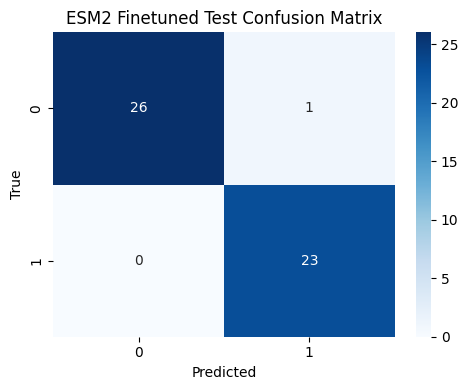

ESM2 finetune test metrics:


,model,feature_set,accuracy,precision,recall,f1,roc_auc,log_loss
0,ESM2_Finetuned,sequence_only,0.98,0.958333,1.0,0.978723,1.0,0.295636


Saved:
- /mmfs1/scratch/mmishkatur.rahman/Escape/runs/2026-03-24_antigen_struct_esm2_8M_esmfold_hpo_v1/metrics_hpo/esm2_finetune_test_metrics.json
- /mmfs1/scratch/mmishkatur.rahman/Escape/runs/2026-03-24_antigen_struct_esm2_8M_esmfold_hpo_v1/metrics_hpo/history_esm2_finetune.csv
- /mmfs1/scratch/mmishkatur.rahman/Escape/runs/2026-03-24_antigen_struct_esm2_8M_esmfold_hpo_v1/plots_hpo/confusion_matrix_esm2_finetune_test.png
- /mmfs1/scratch/mmishkatur.rahman/Escape/runs/2026-03-24_antigen_struct_esm2_8M_esmfold_hpo_v1/metrics_hpo/summary_with_esm2_finetune.csv
Comparison table (existing HPO models + ESM2 finetune):


,model,feature_set,accuracy,precision,recall,f1,roc_auc,log_loss
0,ESM2_Finetuned,sequence_only,0.98,0.958333,1.000000,0.978723,1.000000,0.295636
1,GPSConv,embedding_only,0.94,0.916667,0.956522,0.936170,0.996779,0.191900
2,XGBoost,embedding_only,0.94,0.884615,1.000000,0.938776,0.990338,0.185662
3,XGBoost,combined,0.92,0.880000,0.956522,0.916667,0.988728,0.169095
4,GAT,combined,0.94,0.916667,0.956522,0.936170,0.985507,0.200085
5,GAT,embedding_only,0.94,0.916667,0.956522,0.936170,0.985507,0.197586
6,DNN,embedding_only,0.92,0.913043,0.913043,0.913043,0.982287,0.222466
7,GPSConv,combined,0.94,0.916667,0.956522,0.936170,0.980676,0.189293
8,TransformerConv,embedding_only,0.90,0.875000,0.913043,0.893617,0.980676,0.195465
9,DNN,combined,0.92,0.913043,0.913043,0.913043,0.971014,0.224996


In [13]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
)

try:
    from datasets import Dataset, DatasetDict
    from transformers import AutoTokenizer, EsmForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
except Exception as e:
    raise ImportError(
        "This optional benchmark needs `datasets` and `transformers`. "
        "Install with: python -m pip install -U datasets transformers"
    ) from e

# ----------------------------
# 1) Reuse active notebook df + exact existing split masks
# ----------------------------
if SEQ_COL not in df.columns or Y_COL not in df.columns:
    raise ValueError(
        f"Current in-memory df must contain '{SEQ_COL}' and '{Y_COL}'. "
        "Run the earlier data prep cells first."
    )

if "train_mask" not in globals() or "val_mask" not in globals() or "test_mask" not in globals():
    raise ValueError("Expected train_mask/val_mask/test_mask in kernel. Run the split cell first.")

df_seq = df[[ID_COL, SEQ_COL, Y_COL]].copy()
df_seq[SEQ_COL] = df_seq[SEQ_COL].astype(str).str.upper().str.replace(r"\\s+", "", regex=True)
df_seq[Y_COL] = pd.to_numeric(df_seq[Y_COL], errors="coerce").fillna(0).astype(int)

train_mask_np = _mask_np(train_mask) if "_mask_np" in globals() else np.asarray(train_mask.cpu().numpy(), dtype=bool)
val_mask_np = _mask_np(val_mask) if "_mask_np" in globals() else np.asarray(val_mask.cpu().numpy(), dtype=bool)
test_mask_np = _mask_np(test_mask) if "_mask_np" in globals() else np.asarray(test_mask.cpu().numpy(), dtype=bool)

if len(df_seq) != len(train_mask_np):
    raise ValueError("Length mismatch between df and split masks. Re-run the split/modeling setup cell.")

train_df = df_seq.loc[train_mask_np].reset_index(drop=True)
val_df = df_seq.loc[val_mask_np].reset_index(drop=True)
test_df = df_seq.loc[test_mask_np].reset_index(drop=True)

print("Reused split sizes:", len(train_df), len(val_df), len(test_df))

dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})

# ----------------------------
# 3) Tokenize + model
# ----------------------------
ESM2_FINETUNE_CHECKPOINT = ESM2_MODEL
tokenizer = AutoTokenizer.from_pretrained(ESM2_FINETUNE_CHECKPOINT, cache_dir=str(DIR_HF_CACHE))

def _tok(batch):
    return tokenizer(
        batch[SEQ_COL],
        truncation=True,
        max_length=int(ESM2_TOKENIZER_MAX_LENGTH),
        padding="max_length",
    )

encoded = dataset_dict.map(_tok, batched=True)
encoded = encoded.rename_column(Y_COL, "labels")
encoded = encoded.remove_columns([c for c in encoded["train"].column_names if c not in {"input_ids", "attention_mask", "labels"}])
encoded.set_format(type="torch")

model = EsmForSequenceClassification.from_pretrained(
    ESM2_FINETUNE_CHECKPOINT,
    num_labels=2,
    cache_dir=str(DIR_HF_CACHE),
)

def _compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = probs / np.clip(probs.sum(axis=1, keepdims=True), 1e-12, None)
    p1 = probs[:, 1]
    pred = (p1 >= 0.5).astype(int)
    out = {
        "accuracy": float(accuracy_score(labels, pred)),
        "precision": float(precision_score(labels, pred, zero_division=0)),
        "recall": float(recall_score(labels, pred, zero_division=0)),
        "f1": float(f1_score(labels, pred, zero_division=0)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(labels, p1))
    except Exception:
        out["roc_auc"] = float("nan")
    try:
        out["log_loss"] = float(log_loss(labels, np.clip(p1, 1e-6, 1 - 1e-6)))
    except Exception:
        out["log_loss"] = float("nan")
    return out

ft_out_dir = DIR_CHECKPOINTS_HPO / "esm2_finetune_benchmark"
ft_out_dir.mkdir(parents=True, exist_ok=True)

args = TrainingArguments(
    output_dir=str(ft_out_dir),
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    greater_is_better=True,
    logging_steps=25,
    disable_tqdm=True,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=encoded["train"],
    eval_dataset=encoded["validation"],
    compute_metrics=_compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=int(EARLY_STOPPING_PATIENCE))],
)

train_output = trainer.train()

pred = trainer.predict(encoded["test"])
logits = pred.predictions
labels = pred.label_ids.astype(int)
probs = np.exp(logits - np.max(logits, axis=1, keepdims=True))
probs = probs / np.clip(probs.sum(axis=1, keepdims=True), 1e-12, None)
p1 = probs[:, 1]
yhat = (p1 >= 0.5).astype(int)

# ----------------------------
# 4) Save finetuned-style outputs
# ----------------------------
esm2_metrics = {
    "model": "ESM2_Finetuned",
    "feature_set": "sequence_only",
    "accuracy": float(accuracy_score(labels, yhat)),
    "precision": float(precision_score(labels, yhat, zero_division=0)),
    "recall": float(recall_score(labels, yhat, zero_division=0)),
    "f1": float(f1_score(labels, yhat, zero_division=0)),
    "roc_auc": float(roc_auc_score(labels, p1)) if len(np.unique(labels)) > 1 else float("nan"),
    "log_loss": float(log_loss(labels, np.clip(p1, 1e-6, 1 - 1e-6))),
    "train_loss": float(getattr(train_output, "training_loss", np.nan)),
}

_save_json(esm2_metrics, DIR_METRICS_HPO / "esm2_finetune_test_metrics.json")

cm = confusion_matrix(labels, yhat)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("ESM2 Finetuned Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
cm_path = DIR_PLOTS_HPO / "confusion_matrix_esm2_finetune_test.png"
plt.savefig(cm_path, dpi=160)
plt.show()

# Trainer history to CSV for loss curve diagnostics
hist_df = pd.DataFrame(trainer.state.log_history)
hist_df.to_csv(DIR_METRICS_HPO / "history_esm2_finetune.csv", index=False)

# ----------------------------
# 5) Compare with other models
# ----------------------------
summary_path = DIR_METRICS_HPO / "summary_all_feature_sets_from_combined_hpo.csv"
rows = []
if summary_path.exists():
    try:
        rows.append(pd.read_csv(summary_path))
    except Exception:
        pass
rows.append(pd.DataFrame([{
    "model": esm2_metrics["model"],
    "feature_set": esm2_metrics["feature_set"],
    "accuracy": esm2_metrics["accuracy"],
    "precision": esm2_metrics["precision"],
    "recall": esm2_metrics["recall"],
    "f1": esm2_metrics["f1"],
    "roc_auc": esm2_metrics["roc_auc"],
    "log_loss": esm2_metrics["log_loss"],
}]))

compare_df = pd.concat(rows, ignore_index=True)
compare_df.to_csv(DIR_METRICS_HPO / "summary_with_esm2_finetune.csv", index=False)

print("ESM2 finetune test metrics:")
display(pd.DataFrame([esm2_metrics])[ ["model","feature_set","accuracy","precision","recall","f1","roc_auc","log_loss"] ])
print("Saved:")
print("-", DIR_METRICS_HPO / "esm2_finetune_test_metrics.json")
print("-", DIR_METRICS_HPO / "history_esm2_finetune.csv")
print("-", cm_path)
print("-", DIR_METRICS_HPO / "summary_with_esm2_finetune.csv")

print("Comparison table (existing HPO models + ESM2 finetune):")
display(compare_df.sort_values(["roc_auc", "f1"], ascending=False, na_position="last").reset_index(drop=True))


In [25]:
import sys, importlib.util
print("Python:", sys.executable)

spec = importlib.util.find_spec("accelerate")
print("accelerate installed:", spec is not None)

if spec is not None:
    import accelerate
    print("accelerate version:", accelerate.__version__)




Python: /mmfs1/home/mmishkatur.rahman/Venvs/vaccine_esmfold_env/bin/python
accelerate installed: True
accelerate version: 1.13.0


### 10. Practical notes

- Start with `RUN_ESMFOLD = False` if you only want to check notebook structure and cached files first.
- Set `RUN_ESMFOLD = True` when you are ready to generate structures on a machine with enough GPU memory.
- If you already have cached structures or `structural_features.csv`, the notebook will reuse them.
- Increase `HPO_N_TRIALS` after the first clean pass if you want a wider search.
- The graph threshold here is intentionally strict at `0.90`, so expect a much sparser graph than the earlier antigen notebook.